# CM3015 Mid-term coursework 

##### Name: Terry
##### Date: 24 Dec 2025

# 1. ABSTRACT

This project aims to compare two supervised learning algorithms, k-Nearest Neighbors (knn) and Decision Trees, both under classification using the Iris and Breast Cancer Wisconsin datasets. The primary objective is to investigate how feature scaling, hyperparameter tuning, and model complexity affect classification accuracy and generalization capability. knn will be implemented from scratch while Decision Tree will be used from scikit learn lib. This study will establish baseline performance on both datasets, examine the impact of feature scaling on knn versus Decision Tree, systematically tune hyperparameters and analyze overfitting through training-test accuracy gaps. Performance will be evaluated using accuracy, precision, recall, F1-score, and confusion matrix. We will seek to validate theoretical properties of distance based(knn) versus rule based(Decision tree) algorithms.

# 2. Introduction

Classification is a fundamental supervised learning task where algorithms learn to predict categorical labels from input features based on training samples. This project examines two different approaches: k-Nearest Neighbors (knn), an instance based lazy learner that store the training data and makes predictions based on nearest similarity and Decision Trees, a rule based learner that constructs hierarchical decision boundaries. Understanding their pros, preprocessing requirements and limitations is essential for selecting appropriate models for real-world applications.

The Iris dataset (Fisher, 1936) is a simple, popular datasets in machine learning which will serve as an effective validation dataset to verify algorithm implementation correctness. The Breast Cancer Wisconsin dataset (Wolberg et al., 1995) presents a more realistic medical diagnostic challenge. This dataset is particularly important as it reflects real world healthcare applications where classification accuracy directly impacts patient outcomes.

Prior research has established that knn performance is highly sensitive to feature scaling due to its reliance on distance metrics while Decision Trees are scale invariant as they only consider feature orderings (Hastie et al., 2009). Additionally, knn is known to be affected by the curse of dimensionality where distance metrics become less meaningful in high dimensional spaces. Decision Trees on the other hand are prone to overfitting without proper regularisation through depth constraints or pruning techniques (James et al., 2013).

This project aims to test these theoretical properties through systematic experimentation and quantify performance differences across datasets with varying characteristics.

## 2.1 Research Questions

1. How do knn and Decision Trees compare in classification accuracy on baseline (unprocessed) data across both simple and complex datasets?

2. What is the impact of feature scaling on knn versus Decision Tree performance?

3. How does hyperparameter tuning affect model accuracy?

4. Which algorithm demonstrates better generalization capability as measured by the training-test accuracy gap?

5. How do misclassification patterns differ between the two algorithms?

# 3. BACKGROUND

## 3.1 k-Nearest Neighbors Algorithm

k-Nearest Neighbors is an instance based learning algorithm that classifies new data points based on their similarity to labeled training examples (Cover & Hart, 1967).

Key Characteristics:
- Lazy Learning: the algorithm stores all training data and defers computation until prediction time
- Distance Sensitivity: Features with larger numerical ranges dominate the distance calculation
- Hyperparameter k: Controls bias-variance tradeoff

## 3.2 Decision Tree Algorithm

A Decision Tree is a rule-based supervised learning algorithm that classifies data by recursively splitting features into hierarchical decision rules (Breiman et al., 1984).

Key Characteristics:
- Eager Learning: Constructs complete model during training phase
- Scale Invariance: Only considers relative ordering of feature values
- Overfitting Tendency: Trees can memorize training data if there is no constraints
- Hyperparameter max_depth: Controls model complexity

## 3.3 Why I use these algorithms?

Both fall under Supervised Learning: Classification but yet they represent fundamentally different machine learning paradigms. knn is a distance based learning algorithm that relies on similarity measures, whereas Decision Trees are rule based models that learn explicit decision boundaries through hierarchical feature splits. This contrast makes them well suited for analysing how preprocessing, model complexity and generalisation behaviour differ across learning approaches.

# 4. METHODOLOGY

## 4.1 Dataset Selection and Characteristics

1. Iris Dataset (Fisher, 1936):
   - Samples: 150
   - Features: 4 (sepal length, sepal width, petal length, petal width)
   - Classes: 3 (Setosa, Versicolor, Virginica)
   - Characteristics: Low dimensionality, balanced class distribution (50 samples per class), continuous numerical features
   - Purpose: Validate implementation correctness on well-known simple dataset

2. Breast Cancer Wisconsin Dataset (Wolberg et al., 1995):
   - Samples: 569
   - Features: 30 
   - Classes: 2 (malignant, benign)
   - Characteristics: High dimensionality, significant feature scale variation, slight class imbalance (~63% benign, ~37% malignant)
   - Purpose: Test algorithms on realistic medical diagnostic task

## 4.2 Experimental Design

The datasets are split into training and testing sets using an 80:20 ratio with stratified sampling, applied to preserve the original class distribution. Model performance is evaluated using multiple classification metrics including accuracy to measure overall correctness, precision to assess the proportion of correctly predicted positive instances, recall to quantify the proportion of actual positives that are correctly identified and the F1-score as the harmonic mean of precision and recall. In addition, confusion matrices are used to provide a detailed visualisation of classification outcomes and error patterns.

## 4.3 knn Implementation from scratch

The k-Nearest Neighbors algorithm is implemented from scratch in pure Python using NumPy for numerical operations. Out of the 2 distance metric from lecture, Euclidean distance is used as the distance metric to measure similarity between data points and class predictions are determined through simple majority voting among the k nearest neighbours. The implementation allows flexible selection of the k parameter to support systematic hyperparameter tuning and performance analysis.

## 4.4 Decision Tree Implementation

Decision Tree classification is implemented using the scikit learn library with the Gini impurity criterion for node splitting. A fixed random state of 40 is applied to ensure reproducibility of results. Hyperparameters are initially set to their default values and subsequently tuned to analyse the effects of model complexity and regularisation on classification performance.

## 4.5 Experimental Workflow

1. Baseline Performance on Iris Dataset
2. Baseline Performance on Breast Cancer Dataset
3. Feature Scaling Impact Analysis
4. Hyperparameter Tuning
5. Overfitting Analysis
6. Error Analysis via Confusion Matrices

# 5. Results

## Imports and Setup

In [87]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_recall_fscore_support

## KNN implementation from scratch in python code

In [88]:
# Calculate Euclidean distance between two points
def euclidean_distance(point1, point2):
    
    return np.sqrt(np.sum((point1 - point2) ** 2))

class KNN_From_Scratch:

    # Arg k: number of neighbours to consider
    def __init__(self, k = 3):
        
        self.k = k
        self.X_train = None
        self.y_train = None

    # Store train features and labels
    def fit(self, X_train, y_train):
        
        self.X_train = X_train
        self.y_train = y_train
        return self

    # Predict class labels for test data
    def predict(self, X_test):
        
        predictions = []
        
        for test_point in X_test:
            # Calculate distances to all training points
            distances = []
            for i in range(len(self.X_train)):
                dist = euclidean_distance(test_point, self.X_train[i])
                distances.append((dist, self.y_train[i]))
            
            # Sort by distance (ascending)
            distances.sort(key=lambda x: x[0])
            
            # Get k nearest neighbors
            k_nearest = distances[:self.k]
            
            # Get the labels from k_nearest
            k_labels = [label for _, label in k_nearest]
            # Pick the label with more neighbours as most_common
            most_common = max(set(k_labels), key = k_labels.count)
            predictions.append(most_common)
        
        return np.array(predictions)

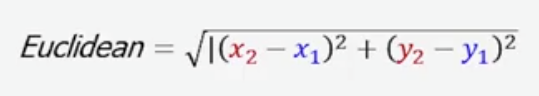

## Baseline performance on Iris dataset from scikit learn library

In [89]:
# Load Iris dataset
iris = datasets.load_iris()
X_iris = iris.data
y_iris = iris.target

print(f"\nDataset: Iris")
print(f"Samples: {X_iris.shape[0]}")
print(f"Features: {X_iris.shape[1]} {iris.feature_names}")
print(f"Classes: {len(iris.target_names)} {iris.target_names}")

# Train/test split
X_train_iris, X_test_iris, y_train_iris, y_test_iris = train_test_split(
    X_iris, 
    y_iris, 
    # Split datasets to 80% train 20% test
    test_size = 0.2, 
    # Fixed random_state=40 for reproducibility
    random_state = 40, 
    # Stratify keeps the class ratios fair across splits
    stratify = y_iris
)

print(f"Training samples: {len(X_train_iris)}")
print(f"Testing samples: {len(X_test_iris)}")


Dataset: Iris
Samples: 150
Features: 4 ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Classes: 3 ['setosa' 'versicolor' 'virginica']
Training samples: 120
Testing samples: 30


## knn Classification Report (Iris dataset)

In [90]:
# knn from scratch
knn_iris = KNN_From_Scratch(k=3)
knn_iris.fit(X_train_iris, y_train_iris)
pred_knn_iris = knn_iris.predict(X_test_iris)
acc_knn_iris = accuracy_score(y_test_iris, pred_knn_iris)

print(f"Accuracy: {acc_knn_iris:.4f}")
print("\nClassification Report: \n")
print(classification_report(y_test_iris, pred_knn_iris, target_names = iris.target_names))

Accuracy: 0.9667

Classification Report: 

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.91      1.00      0.95        10
   virginica       1.00      0.90      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



## Decision tree Classification Report (Iris dataset)

In [91]:
# Decision Tree
dt_iris = DecisionTreeClassifier(random_state = 40)
dt_iris.fit(X_train_iris, y_train_iris)
pred_dt_iris = dt_iris.predict(X_test_iris)
acc_dt_iris = accuracy_score(y_test_iris, pred_dt_iris)

print(f"Accuracy: {acc_dt_iris:.4f}")
print("\nClassification Report: \n")
print(classification_report(y_test_iris, pred_dt_iris, target_names = iris.target_names))

Accuracy: 0.9000

Classification Report: 

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.89      0.80      0.84        10
   virginica       0.82      0.90      0.86        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30



In [92]:
print("Finding: knn outperforms Decision Tree.")
print(f"knn: {acc_knn_iris:.4f} > dt: {acc_dt_iris:.4f}")

Finding: knn outperforms Decision Tree.
knn: 0.9667 > dt: 0.9000


since Iris dataset has only 150 samples, which I think is not sufficient for model evaluation, I had included knn and dt algorithm on both Iris and Breast Cancer Wiscosin dataset with feature scaling, hyperparameter tuning and overfitting analysis on breast cancer data.

# Baseline performance on Breast cancer dataset from scikit learn library

In [93]:
# Load Breast Cancer dataset
cancer = datasets.load_breast_cancer()
X_base = cancer.data
y_base = cancer.target

print(f"\nDataset: Breast Cancer Wisconsin")
print(f"Samples: {X_base.shape[0]}")
print(f"Features: {X_base.shape[1]}")
print(f"Classes: {len(cancer.target_names)} {cancer.target_names}")

# Train/test split
X_train_base, X_test_base, y_train_base, y_test_base = train_test_split(
    X_base, 
    y_base, 
    # Split datasets to 80% train 20% test
    test_size = 0.2, 
    # Fixed random_state=40 for reproducibility
    random_state = 40, 
    # Stratify keeps the class ratios fair across splits
    stratify = y_base
)

print(f"Training samples: {len(X_train_base)}")
print(f"Testing samples: {len(X_test_base)}")


Dataset: Breast Cancer Wisconsin
Samples: 569
Features: 30
Classes: 2 ['malignant' 'benign']
Training samples: 455
Testing samples: 114


## knn Classification Report before scaling (Breast cancer dataset)

In [94]:
# knn from scratch (unscaled)
knn_base = KNN_From_Scratch(k=3)
knn_base.fit(X_train_base, y_train_base)
pred_knn_base = knn_base.predict(X_test_base)
acc_knn_base = accuracy_score(y_test_base, pred_knn_base)

print(f"Accuracy: {acc_knn_base:.4f}")
print("\nClassification Report: \n")
print(classification_report(y_test_base, pred_knn_base, target_names = cancer.target_names))

Accuracy: 0.9386

Classification Report: 

              precision    recall  f1-score   support

   malignant       0.93      0.90      0.92        42
      benign       0.95      0.96      0.95        72

    accuracy                           0.94       114
   macro avg       0.94      0.93      0.93       114
weighted avg       0.94      0.94      0.94       114



## Decision Tree Classification Report before scaling (Breast cancer dataset)

In [95]:
# Decision Tree (unscaled)
dt_base = DecisionTreeClassifier(random_state = 40)
dt_base.fit(X_train_base, y_train_base)
pred_dt_base = dt_base.predict(X_test_base)
acc_dt_base = accuracy_score(y_test_base, pred_dt_base)

print(f"Accuracy: {acc_dt_base:.4f}")
print("\nClassification Report: \n")
print(classification_report(y_test_base, pred_dt_base, target_names = cancer.target_names))

Accuracy: 0.9561

Classification Report: 

              precision    recall  f1-score   support

   malignant       0.91      0.98      0.94        42
      benign       0.99      0.94      0.96        72

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114



In [96]:
print("Finding: Decision Tree slightly outperforms knn without scaling.")
print(f"dt: {acc_dt_base:.4f} > knn: {acc_knn_base:.4f}")

Finding: Decision Tree slightly outperforms knn without scaling.
dt: 0.9561 > knn: 0.9386


# Feature scaling impact

Feature scaling is applied to ensure that all features contribute equally to distance calculations. This is essential for knn which relies on Euclidean distance but has little effect on Decision Trees which use threshold based splits rather than distance measures.

#### HYPOTHESIS: Feature scaling should improve knn but should not have affect on Decision Tree

In [97]:
# Apply StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_base)
X_test_scaled = scaler.transform(X_test_base)

## knn Classification Report after scaling (Breast cancer dataset)

In [98]:
# knn with scaled data
knn_scaled = KNN_From_Scratch(k=3)
knn_scaled.fit(X_train_scaled, y_train_base)
# Make prediction on test data
pred_knn_scaled = knn_scaled.predict(X_test_scaled)
# Evaluate accuracy score
acc_knn_scaled = accuracy_score(y_test_base, pred_knn_scaled)

print(f"Accuracy: {acc_knn_scaled:.4f}")
print("\nClassification Report: \n")
print(classification_report(y_test_base, pred_knn_scaled, target_names = cancer.target_names))

Accuracy: 0.9825

Classification Report: 

              precision    recall  f1-score   support

   malignant       1.00      0.95      0.98        42
      benign       0.97      1.00      0.99        72

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



## Decision Tree Classification Report after scaling (Breast cancer dataset)

In [99]:
# Decision Tree with scaled data
dt_scaled = DecisionTreeClassifier(random_state = 40)
dt_scaled.fit(X_train_scaled, y_train_base)
# Make prediction on test data
pred_dt_scaled = dt_scaled.predict(X_test_scaled)
# Evaluate accuracy score
acc_dt_scaled = accuracy_score(y_test_base, pred_dt_scaled)

print(f"Accuracy: {acc_dt_scaled:.4f}")
print("\nClassification Report: \n")
print(classification_report(y_test_base, pred_dt_scaled, target_names=cancer.target_names))

Accuracy: 0.9561

Classification Report: 

              precision    recall  f1-score   support

   malignant       0.91      0.98      0.94        42
      benign       0.99      0.94      0.96        72

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114



## Scaling Comparison

In [100]:
scaling_comparison = pd.DataFrame({
    'Algorithm': ['knn', 'Decision Tree'],
    'Unscaled Accuracy': [acc_knn_base, acc_dt_base],
    'Scaled Accuracy': [acc_knn_scaled, acc_dt_scaled],
    'Improvement (%)': [(acc_knn_scaled - acc_knn_base) * 100, (acc_dt_scaled - acc_dt_base) * 100]
})

# Rounded to look nicer
scaling_comparison = scaling_comparison.round({
    'Unscaled Accuracy': 4,
    'Scaled Accuracy': 4,
    'Improvement (%)': 2
})

display(scaling_comparison)

,Algorithm,Unscaled Accuracy,Scaled Accuracy,Improvement (%)
0,knn,0.9386,0.9825,4.39
1,Decision Tree,0.9561,0.9561,0.00


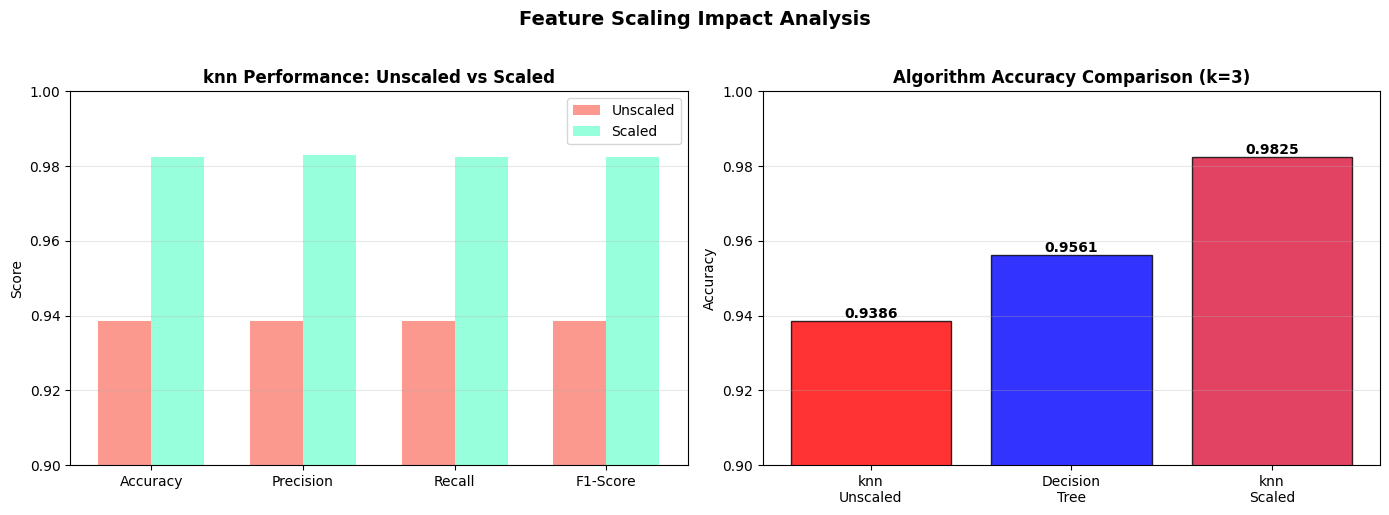

In [101]:
# Visualization: Scaling impact on knn metrics
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart: knn metrics comparison
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
prec_knn_scaled, rec_knn_scaled, f1_knn_scaled, _ = precision_recall_fscore_support(y_test_base, pred_knn_scaled, average = 'weighted')
unscaled_vals = [acc_knn_base, prec_knn_base, rec_knn_base, f1_knn_base]
scaled_vals = [acc_knn_scaled, prec_knn_scaled, rec_knn_scaled, f1_knn_scaled]

x = np.arange(len(metrics))
width = 0.35

axes[0].bar(x - width/2, unscaled_vals, width, label = 'Unscaled', color = 'salmon', alpha = 0.8)
axes[0].bar(x + width/2, scaled_vals, width, label = 'Scaled', color = 'aquamarine', alpha = 0.8)
axes[0].set_ylabel('Score')
axes[0].set_title('knn Performance: Unscaled vs Scaled', fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)
axes[0].set_ylim([0.9, 1.0])

# Histogram: Algorithm comparison
algorithms = ['knn\nUnscaled', 'Decision\nTree', 'knn\nScaled']
accuracies = [acc_knn_base, acc_dt_base, acc_knn_scaled]
colors = ['red', 'blue', 'crimson']

bars = axes[1].bar(algorithms, accuracies, color = colors, alpha = 0.8, edgecolor = 'black')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Algorithm Accuracy Comparison (k=3)', fontweight = 'bold')
axes[1].set_ylim([0.9, 1.0])
axes[1].grid(axis='y', alpha=0.3)

for bar in bars:
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height, f'{height:.4f}', ha = 'center', va = 'bottom', fontweight = 'bold')

plt.suptitle('Feature Scaling Impact Analysis', fontsize = 14, fontweight = 'bold', y = 1.02)
plt.tight_layout()
plt.show()

## Hyperparameter Tuning (knn)

In [102]:
k_values = [1, 3, 5, 7, 9, 11, 15, 25, 50]
k_scores = []

for k in k_values:
    # Temporary knn to store each k
    knn_temp = KNN_From_Scratch(k = k)
    knn_temp.fit(X_train_scaled, y_train_base)
    # Make prediction on test data
    pred = knn_temp.predict(X_test_scaled)
    # Evaluate accuracy score
    score = accuracy_score(y_test_base, pred)
    k_scores.append(score)
    print(f"k = {k:2d}: Test Accuracy = {score:.4f}")

# Find optimal k
optimal_k = k_values[np.argmax(k_scores)]
optimal_score = max(k_scores)
print(f"\nOptimal k = {optimal_k} with accuracy = {optimal_score:.4f}")

k =  1: Test Accuracy = 0.9649
k =  3: Test Accuracy = 0.9825
k =  5: Test Accuracy = 0.9912
k =  7: Test Accuracy = 0.9912
k =  9: Test Accuracy = 0.9912
k = 11: Test Accuracy = 0.9912
k = 15: Test Accuracy = 0.9912
k = 25: Test Accuracy = 0.9825
k = 50: Test Accuracy = 0.9737

Optimal k = 5 with accuracy = 0.9912


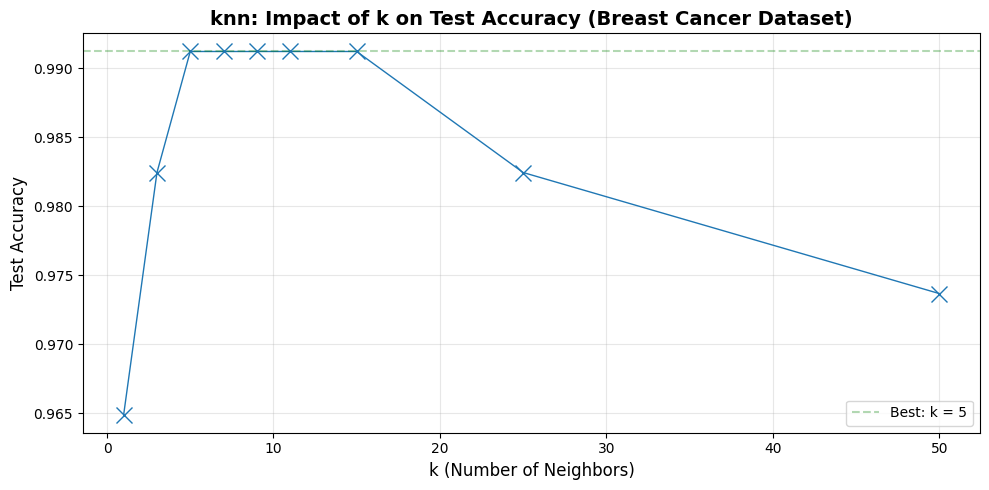

In [103]:
# Plot k vs accuracy
plt.figure(figsize = (10, 5))
plt.plot(k_values, k_scores, marker = 'x', linewidth = 1, markersize = 12)
plt.axhline(y = optimal_score, color = 'g', linestyle = '--', alpha = 0.3, label = f'Best: k = {optimal_k}')
plt.xlabel('k (Number of Neighbors)', fontsize = 12)
plt.ylabel('Test Accuracy', fontsize = 12)
plt.title('knn: Impact of k on Test Accuracy (Breast Cancer Dataset)', fontsize = 14, fontweight = 'bold')
plt.grid(True, alpha = 0.3)
plt.legend()
plt.tight_layout()
plt.show()

## Hyperparameter Tuning (Decision Tree)

In [104]:
depths = [2, 5, 10, 15, 20, None]
depth_train_scores = []
depth_test_scores = []

for depth in depths:
    # Temporary dt to store each depth
    dt_temp = DecisionTreeClassifier(max_depth = depth, random_state = 40)
    dt_temp.fit(X_train_scaled, y_train_base)
    
    train_score = dt_temp.score(X_train_scaled, y_train_base)
    test_score = dt_temp.score(X_test_scaled, y_test_base)
    
    depth_train_scores.append(train_score)
    depth_test_scores.append(test_score)
    
    depth_label = "None" if depth is None else str(depth)
    print(f"max_depth = {depth_label:10}: Train = {train_score:.4f} | Test = {test_score:.4f} | Gap = {train_score-test_score:.4f}")

# Find optimal depth
optimal_idx = np.argmax(depth_test_scores)
optimal_depth = depths[optimal_idx]
optimal_test = depth_test_scores[optimal_idx]
print(f"\n Optimal max_depth = {optimal_depth} with test accuracy = {optimal_test:.4f}")

max_depth = 2         : Train = 0.9516 | Test = 0.9386 | Gap = 0.0131
max_depth = 5         : Train = 0.9956 | Test = 0.9737 | Gap = 0.0219
max_depth = 10        : Train = 1.0000 | Test = 0.9561 | Gap = 0.0439
max_depth = 15        : Train = 1.0000 | Test = 0.9561 | Gap = 0.0439
max_depth = 20        : Train = 1.0000 | Test = 0.9561 | Gap = 0.0439
max_depth = None      : Train = 1.0000 | Test = 0.9561 | Gap = 0.0439

 Optimal max_depth = 5 with test accuracy = 0.9737


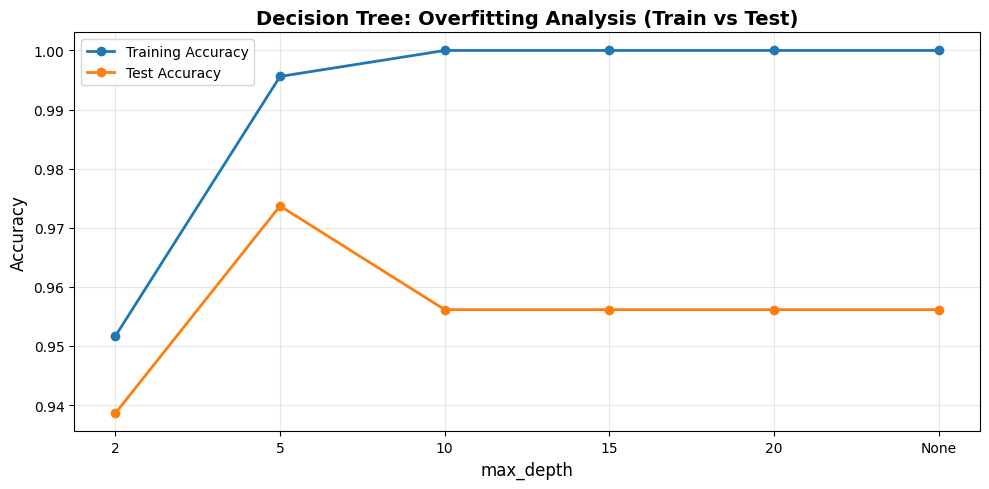

In [105]:
 # Plot train vs test accuracy
depth_labels = [str(d) if d is not None else 'None' for d in depths]
x_pos = np.arange(len(depths))

plt.figure(figsize = (10, 5))
plt.plot(x_pos, depth_train_scores, marker = 'o', label = 'Training Accuracy', linewidth = 2)
plt.plot(x_pos, depth_test_scores, marker = 'o', label = 'Test Accuracy', linewidth = 2)
plt.xticks(x_pos, depth_labels)
plt.xlabel('max_depth', fontsize = 12)
plt.ylabel('Accuracy', fontsize = 12)
plt.title('Decision Tree: Overfitting Analysis (Train vs Test)', fontsize = 14, fontweight = 'bold')
plt.legend()
plt.grid(True, alpha = 0.3)
plt.tight_layout()
plt.show()

## Overfitting Analysis

In [106]:
# Train final models with optimal hyperparameters
print("Training final models with optimal hyperparameters")
print(f"knn: k = {optimal_k}")
print(f"Decision Tree: max_depth = {optimal_depth}")

# knn final model
knn_final = KNN_From_Scratch(k = optimal_k)
knn_final.fit(X_train_scaled, y_train_base)
knn_train_acc = accuracy_score(y_train_base, knn_final.predict(X_train_scaled))
knn_test_acc = accuracy_score(y_test_base, knn_final.predict(X_test_scaled))

# Decision Tree final model
dt_final = DecisionTreeClassifier(max_depth = optimal_depth, random_state = 40)
dt_final.fit(X_train_scaled, y_train_base)
dt_train_acc = dt_final.score(X_train_scaled, y_train_base)
dt_test_acc = dt_final.score(X_test_scaled, y_test_base)

# Create overfitting summary table
overfitting_summary = pd.DataFrame({
    'Algorithm': [f'knn (k = {optimal_k})', 'Decision Tree'],
    'Train Accuracy': [knn_train_acc, dt_train_acc],
    'Test Accuracy': [knn_test_acc, dt_test_acc]
})

# Compute generalisation gap
overfitting_summary['Gap'] = (
    overfitting_summary['Train Accuracy'] - overfitting_summary['Test Accuracy']
)

# Flag overfitting
overfitting_summary['Overfitting'] = overfitting_summary['Gap'].apply(
    lambda g: 'Yes' if g > 0.05 else ('Minimal' if g > 0 else 'No')
)

# Round values for readability
overfitting_summary = overfitting_summary.round(4)

print("\nOverfitting Analysis Summary")
display(overfitting_summary)

Training final models with optimal hyperparameters
knn: k = 5
Decision Tree: max_depth = 5

Overfitting Analysis Summary


,Algorithm,Train Accuracy,Test Accuracy,Gap,Overfitting
0,knn (k = 5),0.9670,0.9912,-0.0242,No
1,Decision Tree,0.9956,0.9737,0.0219,Minimal


## Confusion Matrix

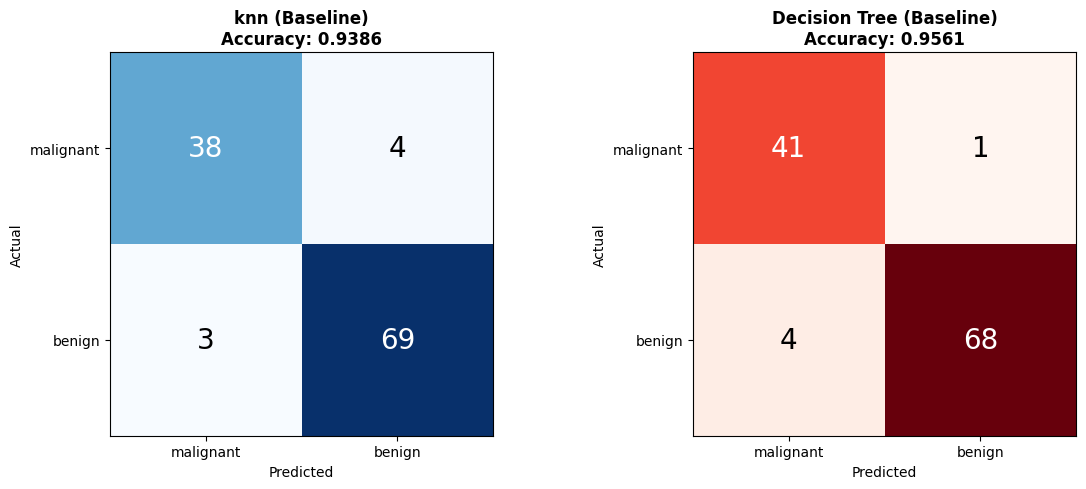

In [107]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# knn confusion matrix (BASELINE / UNSCALED)
cm_knn_base = confusion_matrix(y_test_base, knn_base.predict(X_test_base))
axes[0].imshow(cm_knn_base, cmap = 'Blues')
axes[0].set_title(f'knn (Baseline)\nAccuracy: {acc_knn_base:.4f}', fontsize = 12, fontweight = 'bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_xticks([0, 1])
axes[0].set_yticks([0, 1])
axes[0].set_xticklabels(cancer.target_names)
axes[0].set_yticklabels(cancer.target_names)

for i in range(2):
    for j in range(2):
        axes[0].text( j, i, str(cm_knn_base[i, j]), ha = 'center', va = 'center', fontsize = 20, 
                      color = 'white' if cm_knn_base[i, j] > cm_knn_base.max()/2 else 'black')

# Decision Tree confusion matrix (BASELINE / UNSCALED)
cm_dt_base = confusion_matrix(y_test_base, dt_base.predict(X_test_base))
axes[1].imshow(cm_dt_base, cmap = 'Reds')
axes[1].set_title(f'Decision Tree (Baseline)\nAccuracy: {acc_dt_base:.4f}', fontsize = 12, fontweight = 'bold')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
axes[1].set_xticks([0, 1])
axes[1].set_yticks([0, 1])
axes[1].set_xticklabels(cancer.target_names)
axes[1].set_yticklabels(cancer.target_names)

for i in range(2):
    for j in range(2):
        axes[1].text( j, i, str(cm_dt_base[i, j]), ha = 'center', va = 'center', fontsize = 20, 
                      color = 'white' if cm_dt_base[i, j] > cm_dt_base.max()/2 else 'black')

plt.tight_layout()
plt.show()

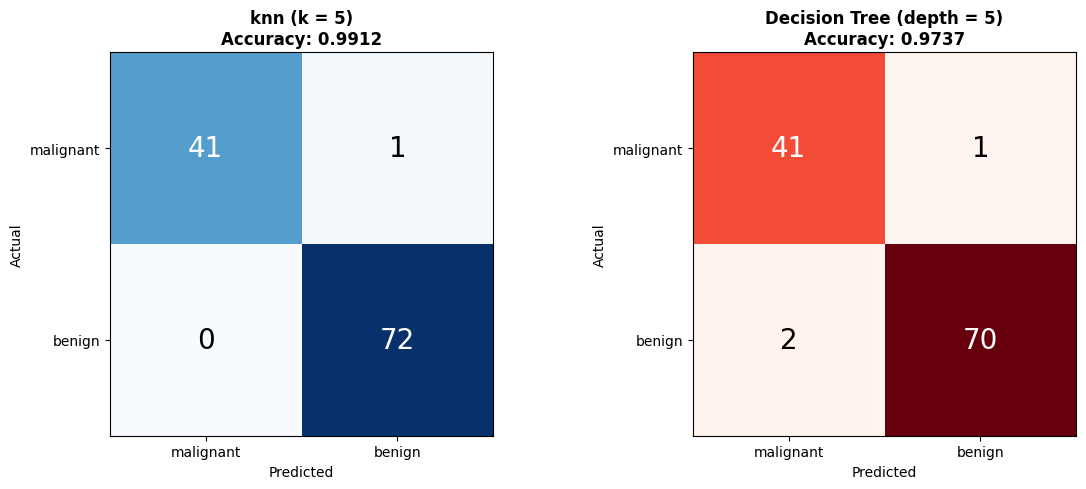

In [108]:
fig, axes = plt.subplots(1, 2, figsize = (12, 5))

# knn confusion matrix
cm_knn = confusion_matrix(y_test_base, knn_final.predict(X_test_scaled))
axes[0].imshow(cm_knn, cmap = 'Blues')
axes[0].set_title(f'knn (k = {optimal_k})\nAccuracy: {knn_test_acc:.4f}', fontsize = 12, fontweight = 'bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_xticks([0, 1])
axes[0].set_yticks([0, 1])
axes[0].set_xticklabels(cancer.target_names)
axes[0].set_yticklabels(cancer.target_names)

for i in range(2):
    for j in range(2):
        axes[0].text(j, i, str(cm_knn[i, j]), ha = 'center', va = 'center', fontsize = 20, 
                     color = 'white' if cm_knn[i, j] > cm_knn.max()/2 else 'black')

# Decision Tree confusion matrix
cm_dt = confusion_matrix(y_test_base, dt_final.predict(X_test_scaled))
axes[1].imshow(cm_dt, cmap = 'Reds')
axes[1].set_title(f'Decision Tree (depth = {optimal_depth})\nAccuracy: {dt_test_acc:.4f}', fontsize = 12, fontweight = 'bold')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
axes[1].set_xticks([0, 1])
axes[1].set_yticks([0, 1])
axes[1].set_xticklabels(cancer.target_names)
axes[1].set_yticklabels(cancer.target_names)

for i in range(2):
    for j in range(2):
        axes[1].text(j, i, str(cm_dt[i, j]), ha = 'center', va = 'center', fontsize = 20, 
                     color = 'white' if cm_dt[i, j] > cm_dt.max()/2 else 'black')

plt.tight_layout()
plt.show()

# 6. Evaluation

## 6.1 Findings from research results

### Iris Dataset Baseline Results

Both algorithms achieved strong performance on the Iris dataset, with knn demonstrating superior accuracy. The nearly perfect performance validates the correctness of the knn implementation. However, these high scores limit the dataset's value for meaningful algorithm comparison as Iris is known to be linearly separable and relatively simple.

### Breast Cancer Dataset Baseline Results (Unscaled)

On the more complex Breast Cancer dataset, Decision Tree initially outperformed knn on unscaled data. This baseline result demonstrates a critical lesson: without proper preprocessing, distance based algorithms underperform. The Breast Cancer dataset contains 30 features with huge different scales. Without scaling, large magnitude features dominate the Euclidean distance calculation.

### Comparison of two datasets

The contrasting baseline results across datasets highlight that algorithm performance is context dependent. knn performed well on Iris dataset without scaling due to relatively similar feature scales, but struggled on Breast Cancer where scale variation is extreme. Decision Tree's consistent performance (90% on Iris, 95.61% on Breast Cancer) confirms its robustness to feature scales, as it only considers relative ordering of values when making splits.

### Feature Scaling Impact

The 4.39% improvement represents a performance gain that completely reversed the algorithm rankings. Before scaling, knn underperformed Decision Tree by 1.75. After scaling, knn outperformed Decision Tree by 2.64. The improvement was consistent across all evaluation metrics (precision, recall, F1-score) demonstrating that scaling affects fundamental prediction capability rather than just overall accuracy.

StandardScaler transformed all features to have mean=0 and standard deviation=1, ensuring equal contribution to distance calculations. Without scaling, some features can dominate over other features.

This result empirically validates the theoretical requirement that distance based algorithms need feature normalization. The perfect invariance of Decision Tree confirms that tree based methods split purely on relative feature orderings.

The comparison demonstrates that preprocessing can fundamentally change algorithm selection decisions. A naive comparison on raw data would conclude Decision Tree is superior (95.61% vs 93.86%), but proper preprocessing reveals knn as the better performer (98.25% vs 95.61%). This teaches us that algorithm benchmarks must account for proper preprocessing.

### knn hyperparameter tuning

The optimal range k=5 to 15 achieved 99.12% accuracy, representing a 0.87 percentage point improvement over the scaled k=3 baseline (98.25%). k=5 to k=15 indicates the model is robust and stable within this range.

The decline beyond k=15 demonstrates the bias-variance tradeoff where very large k values smooth the decision boundary excessively, causing the model to underfit by averaging over too many neighbors. At k=50, the algorithm averages over 50 neighbors which dilutes the local signal with irrelevant distant points. This results in overly smooth, simplistic decision boundaries that miss important local patterns.

### Decision Tree hyperparameter tuning

The optimal depth=5 achieved 97.37% test accuracy, outperforming unlimited depth by 1.76 percentage points despite having much lower training accuracy (99.56% vs 100%). Trees with depth≥10 achieved perfect training accuracy by creating increasingly complex, specific rules that memorize individual training examples. However, these overly specific rules failed to generalize, causing test performance to drop.

### Overfitting analysis

Here we found out that knn exhibited with a negative train-test gap meaning it performed substantially better on unseen test data than on its own training data. A negative gap doesn't mean the model is overfit since overfitting would produce relatively higher training accuracy than test accuracy.

Decision Tree showed a small positive gap indicating minimal but present overfitting. Despite achieving nearly perfect training accuracy the model maintained strong test performance.

### Misclassification from Confusion Matrix

Both algorithms missed a single malignant case. The case might even be the same one for both algorithm. This suggests that some particular tumor sample has ambiguous feature that resemble other characteristics.

The most important distinction is that knn achieved zero false positives while Decision Tree made two false positive errors. In medical diagnostic contexts, this difference can cause huge impact.

## 6.2 Strengths of the Project

This project employs a rigorous and well structured experimental methodology  using stratified train–test splitting and fixed random states to ensure reproducibility. Model performance is evaluated using multiple metrics and experiments progress systematically from baseline evaluation to feature scaling, hyperparameter tuning, and overfitting analysis.

A key strength of the project is the implementation of the k-Nearest Neighbors algorithm from scratch using pure Python and NumPy. The implementation is validated using the Iris dataset for correctness beyond library based algorithm.

The study effectively demonstrates the impact of feature scaling, confirming theoretical expectations that knn benefits from scaling while Decision Trees remain largely unaffected. The use of both a simple benchmark dataset and a realistic medical dataset further strengthens the analysis.

Finally, results are presented clearly through well organised tables and informative visualisations. Pandas DataFrames are used to structure experimental results while plots and confusion matrix provide intuitive insight into performance trends, error patterns and generalisation behaviour.

## 6.3 Limitations and Weaknesses

The experimental design relies on a single 80/20 train–test split with a fixed random state. This mean that the results may be sensitive to the specific data partition used. While this approach ensures consistent and fair comparisons, not using k-fold cross-validation means the results depend on a single data split and do not show how stable or reliable the model performance is across different splits.

In this study, knn was evaluated using only the Euclidean distance, so the results apply specifically to this choice of metric. Other distance measures may produce different performance and could change the optimal value of k. In addition, feature selection or dimensionality reduction (PCA) was not applied which may have limited knn performance in high dimensional data and reduced model interpretability.

Although the Breast Cancer dataset shows some class imbalance, no specialised techniques were used to address it. While stratified sampling helped maintain class proportions and both models performed well on the minority class, results may differ in datasets with more severe imbalance. Furthermore, no statistical significance testing was conducted.

# 7. Conclusions

This project compared k-Nearest Neighbors and Decision Trees on Iris and Breast Cancer Wisconsin datasets to evaluate how feature scaling, hyperparameter tuning, and model complexity affect classification performance.

Key findings:
- Feature scaling dramatically improved knn from 93.86% to 98.25% (+4.39%) while Decision Tree remained unchanged at 95.61%, confirming that distance based algorithms require normalization whereas tree based methods are scale invariant.
- Hyperparameter tuning further optimized performance. knn achieved 99.12% accuracy at k=5-15, declining at k=50 due to oversmoothing. Decision Tree reached 97.37% at depth=5, with deeper trees overfitting severely (100% train, 95.61% test).
- knn demonstrated superior generalization with a negative train-test gap (-2.42%), performing better on unseen data than training data, while Decision Tree showed minimal overfitting. 
- Both algorithms achieved 97.62% sensitivity, but knn attained zero false positives versus Decision Tree's two, making it clinically superior for medical diagnostics where minimizing unnecessary procedures matters.

With proper preprocessing and tuning, knn outperforms Decision Tree (99.12% vs 97.37%) on this dataset. However, algorithm selection must balance accuracy against interpretability, prediction speed, and application requirements. Implementation quality—proper scaling, systematic tuning—matters more than algorithm choice alone.

# 8. References

### Datasets

Fisher, R. A. (1936). The use of multiple measurements in taxonomic problems. Annals of Eugenics, 7(2), 179-188. https://doi.org/10.1111/j.1469-1809.1936.tb02137.x

Wolberg, W. H., Street, W. N., & Mangasarian, O. L. (1995). Breast Cancer Wisconsin (Diagnostic) Data Set. UCI Machine Learning Repository. https://archive.ics.uci.edu/ml/datasets/Breast+Cancer+Wisconsin+(Diagnostic)

### Textbooks

Hastie, T., Tibshirani, R., & Friedman, J. (2009). The Elements of Statistical Learning: Data Mining, Inference, and Prediction (2nd ed.). Springer Series in Statistics. New York: Springer. https://doi.org/10.1007/978-0-387-84858-7

James, G., Witten, D., Hastie, T., & Tibshirani, R. (2013). An Introduction to Statistical Learning with Applications in R. Springer Texts in Statistics. New York: Springer. https://doi.org/10.1007/978-1-4614-7138-7

### Foundational Papers

Cover, T. M., & Hart, P. E. (1967). Nearest neighbor pattern classification. IEEE Transactions on Information Theory, 13(1), 21-27. https://doi.org/10.1109/TIT.1967.1053964

Breiman, L., Friedman, J., Stone, C. J., & Olshen, R. A. (1984). Classification and Regression Trees. Boca Raton, FL: CRC Press.